In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn import metrics
from sklearn.linear_model import LinearRegression

In [2]:
# creating a daaframe
df = pd.read_csv('IceCreamData.csv', sep=';')
df.head()

,temperature,revenue
0,24.566884,534.799028
1,26.005191,625.190122
2,27.790554,660.632289
3,20.595335,487.706960
4,11.503498,316.240194


In [3]:
df.shape

(500, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  500 non-null    float64
 1   revenue      500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [5]:
df.describe()

,temperature,revenue
count,500.000000,500.000000
mean,22.232225,519.554777
std,8.096388,175.686475
min,0.000000,1.000000
25%,17.122258,404.636084
50%,22.392791,528.248328
75%,27.740674,641.325865
max,45.000000,969.291630


In [6]:
df = df.drop(df[df['revenue'] == 1].index)

In [7]:
df.describe()

,temperature,revenue
count,498.000000,498.000000
mean,22.231150,521.637326
std,7.986098,172.926317
min,0.267028,32.546619
25%,17.146833,405.724874
50%,22.392791,529.368565
75%,27.725909,641.926815
max,42.515280,969.291630


### checking for linear relationship

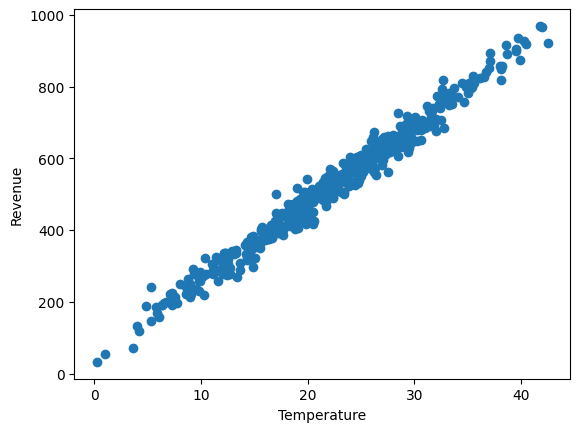

In [8]:
X = df.temperature
y = df.revenue

plt.scatter(X, y) # Plot the original data
plt.xlabel("Temperature")
plt.ylabel("Revenue")
plt.show()

#### From the plot above, we can see that there possibly is a linear relationship between the two variables: Temperature and Revenue, due to the linear trend of the data.

## Fitting the model

In [9]:
# linear model
lm = LinearRegression()
X = np.array(X).reshape(-1,1)
lm.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


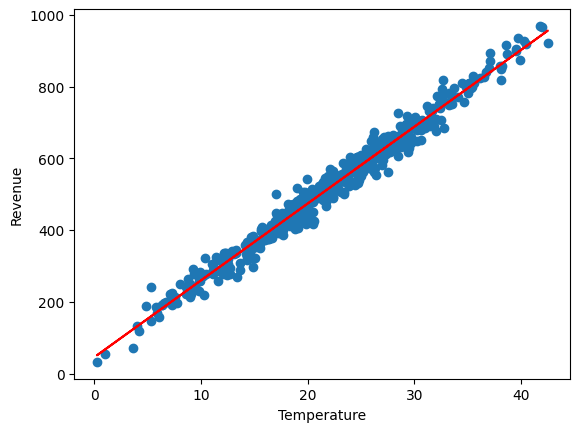

MSE: 622.9426635138749
Residual sum of squares: 310225.4464299097
R_squared: 0.9791263285423254


In [10]:
# Use the fitted model to generate Y values from the X values
y_pred = lm.predict(X)

plt.scatter(X, y) # Plot the original data
plt.plot(X, y_pred, color = 'red') # Plot the line connecting the generated y-values
plt.ylabel("Revenue")
plt.xlabel("Temperature")

plt.show()

print('MSE:', metrics.mean_squared_error(y, y_pred))
print("Residual sum of squares:", metrics.mean_squared_error(y, y_pred)*len(X)) 
print('R_squared:', metrics.r2_score(y, y_pred))

- The model explains about 97.9% of the variation in the target variable, indicating a very strong fit between the predictions and the actual data.

In [11]:
# predicting the Revenue for Temperature = 25
today_temp = 25

today_temp = np.array(today_temp).reshape(-1, 1)
revenue_predict = np.round(lm.predict(today_temp), 2)

print("Today's expected revenue: ", revenue_predict)


Today's expected revenue:  [580.96]


### saving and restoring the model

In [12]:
import pickle

# Save the model 
model_save_path = "lr_model.pkl"
with open(model_save_path,'wb') as file:
    pickle.dump(lm,file)

In [16]:
# restore the model to predict today's revenue
model_load_path = "lr_model.pkl"
with open(model_load_path,'rb') as file:
    unpickled_model = pickle.load(file)

today_temp = 25 # assuming this today's temperature 

today_temp = np.array(today_temp).reshape(-1, 1)
revenue_predict = unpickled_model.predict(today_temp)

print("Today's revenue prediction: ", revenue_predict)



Today's revenue prediction:  [580.96335465]
